In [2]:
import pandas as pd
import joblib
import sys
import os
from pathlib import Path

# Connect to your src folder
project_root = Path(os.getcwd()).resolve().parent
sys.path.append(str(project_root))

# Import your plot functions
from src.train import (
    train_logistic_regression, train_random_forest, train_xgboost, evaluate_model,
    plot_tournament_roc, plot_model_confusion_matrix, plot_lr_coefficients, 
    plot_tree_importances, plot_shap_explanations, calculate_portfolio_loss)

In [3]:
data_dir = Path("../data") 

train_df = pd.read_csv(data_dir / 'train_processed.csv')
test_df = pd.read_csv(data_dir / 'test_processed.csv')

X_train = train_df.drop(columns=['is_high_risk'])
y_train = train_df['is_high_risk']

X_test = test_df.drop(columns=['is_high_risk'])
y_test = test_df['is_high_risk']

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (76529, 15), Test shape: (19133, 15)


In [4]:
# Train out live models
lr_model = train_logistic_regression(X_train, y_train)
rf_model = train_random_forest(X_train, y_train)
xgb_model = train_xgboost(X_train, y_train)

# Dictionary of our tournament contestants for mapping loops
best_models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
}

2026-06-09 11:07:03,318 [INFO] Training Logistic Regression...
2026-06-09 11:07:29,650 [INFO] Training Random Forest...
2026-06-09 11:10:29,219 [INFO] Training XGBoost...


In [5]:
test_results = []
for name, model in [
    ("Logistic Regression", lr_model),
    ("Random Forest", rf_model),
    ("XGBoost", xgb_model),
]:
    # FIX: Use X_test and y_test instead!
    metrics = evaluate_model(model, X_test, y_test, split_name=f"{name} [Test]")
    metrics["model"] = name
    test_results.append(metrics)

df_results = pd.DataFrame(test_results).set_index("model")[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
df_results

2026-06-09 11:10:41,622 [INFO] 
Logistic Regression [Test] Results
2026-06-09 11:10:41,622 [INFO]   accuracy    : 0.7966
2026-06-09 11:10:41,622 [INFO]   precision   : 0.3529
2026-06-09 11:10:41,622 [INFO]   recall      : 0.9201
2026-06-09 11:10:41,622 [INFO]   f1          : 0.5101
2026-06-09 11:10:41,629 [INFO]   roc_auc     : 0.9164
2026-06-09 11:10:41,645 [INFO] 
              precision    recall  f1-score   support

    Good (0)       0.99      0.78      0.87     16931
 Default (1)       0.35      0.92      0.51      2202

    accuracy                           0.80     19133
   macro avg       0.67      0.85      0.69     19133
weighted avg       0.91      0.80      0.83     19133

2026-06-09 11:10:42,406 [INFO] 
Random Forest [Test] Results
2026-06-09 11:10:42,406 [INFO]   accuracy    : 0.9932
2026-06-09 11:10:42,418 [INFO]   precision   : 0.9667
2026-06-09 11:10:42,418 [INFO]   recall      : 0.9741
2026-06-09 11:10:42,419 [INFO]   f1          : 0.9704
2026-06-09 11:10:42,419 [IN

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.796634,0.352900,0.920073,0.510135,0.916367
Random Forest,0.993153,0.966652,0.974114,0.970369,0.999507
XGBoost,0.976010,0.827508,1.000000,0.905614,0.997999


In [7]:
# Automatically generate a perfectly formatted Markdown table from your actual test results
print(df_results.to_markdown(index=False))

|   accuracy |   precision |   recall |       f1 |   roc_auc |
|-----------:|------------:|---------:|---------:|----------:|
|   0.796634 |    0.3529   | 0.920073 | 0.510135 |  0.916367 |
|   0.993153 |    0.966652 | 0.974114 | 0.970369 |  0.999507 |
|   0.97601  |    0.827508 | 1        | 0.905614 |  0.997999 |


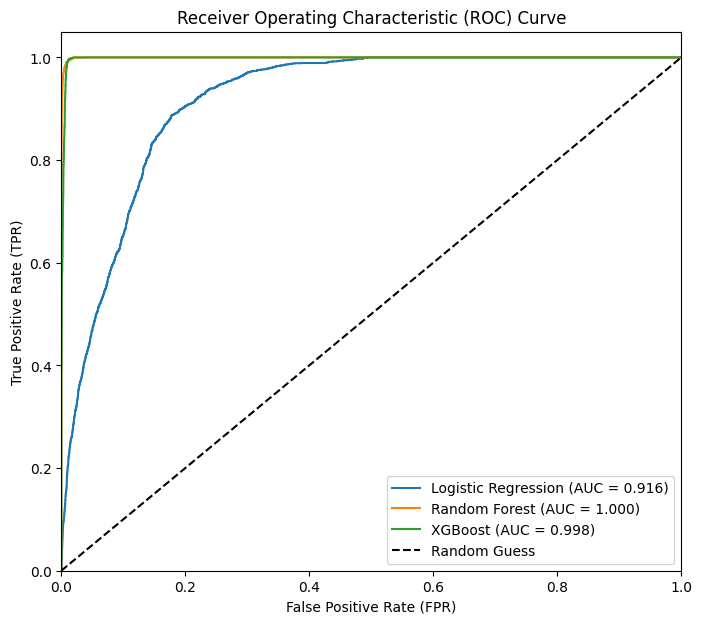

In [ ]:
# Pass the dictionary directly to trace curves instantly
plot_tournament_roc(best_models, X_test, y_test)

🏆 The automated winner is: Random Forest with an AUC of 0.9995!


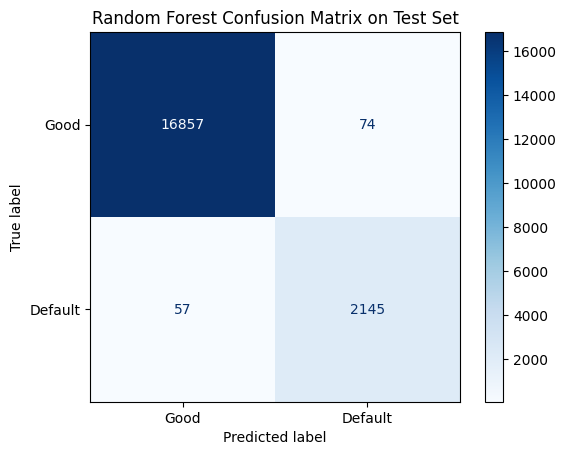

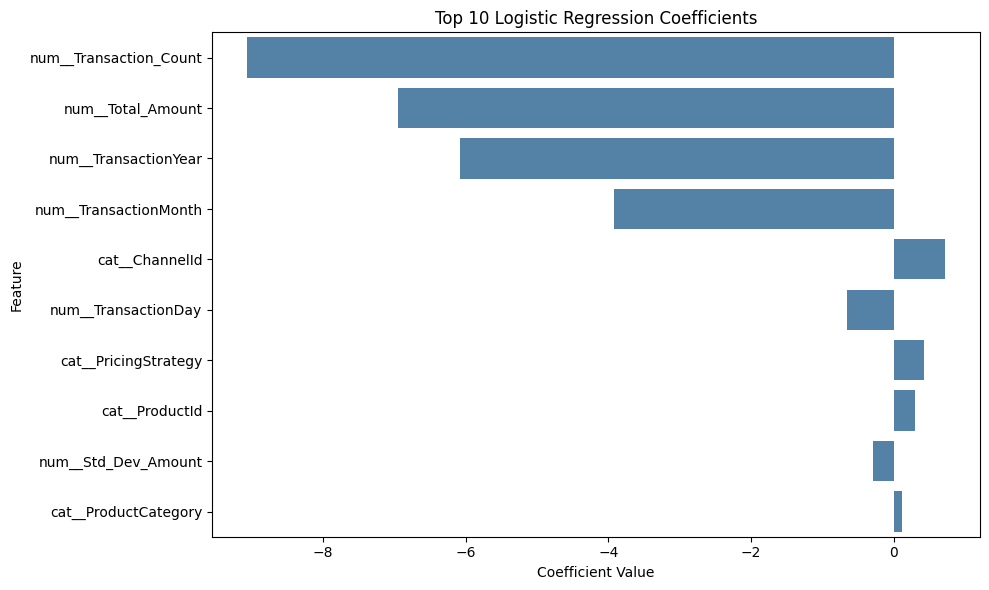

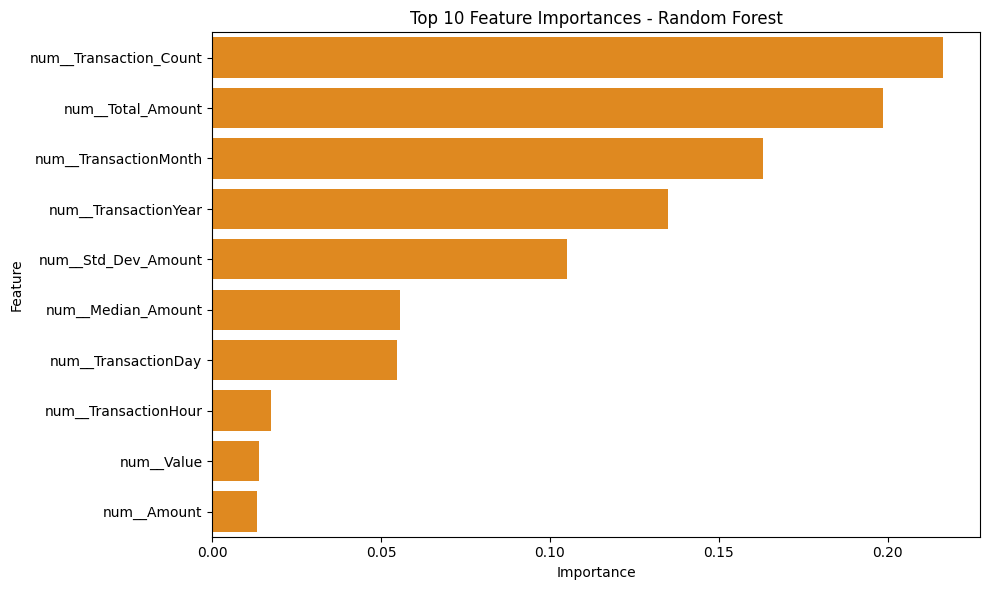

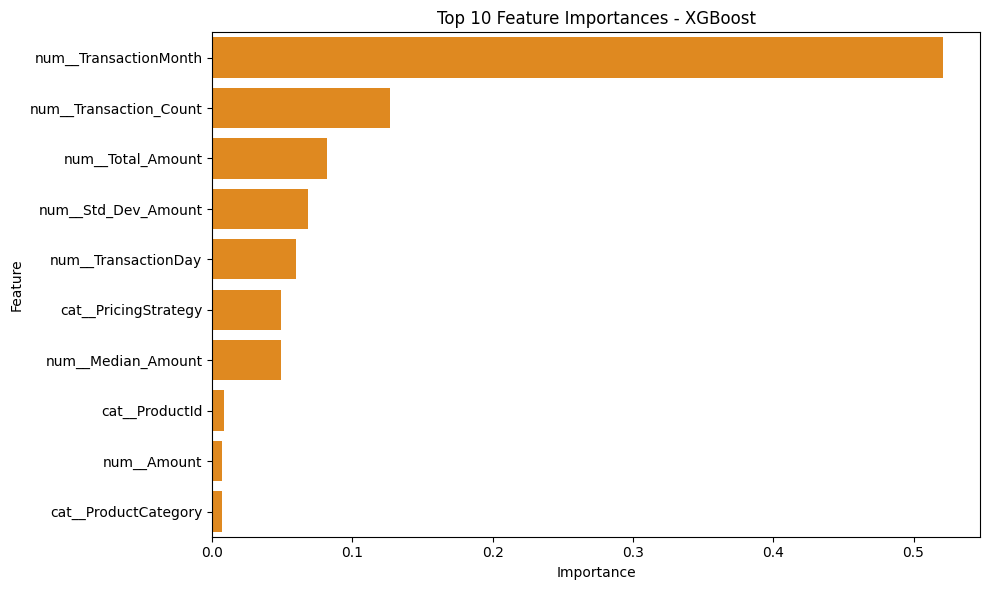

In [ ]:
from sklearn.metrics import roc_auc_score

# 1. Automatically calculate the winner based on test data
scores = {}
for name, model in best_models.items():
    probs = model.predict_proba(X_test)[:, 1]
    scores[name] = roc_auc_score(y_test, probs)

best_model_name = max(scores, key=scores.get)
best_model = best_models[best_model_name]

print(f"🏆 The automated winner is: {best_model_name} with an AUC of {scores[best_model_name]:.4f}!")

# 2. Plot Confusion Matrix for the absolute winner
plot_model_confusion_matrix(best_model, X_test, y_test, best_model_name)

# 3. Global Interpretability weights (What the models care about overall)
plot_lr_coefficients(lr_model, feature_names=X_train.columns)
plot_tree_importances(rf_model, feature_names=X_train.columns, model_name="Random Forest")
plot_tree_importances(xgb_model, feature_names=X_train.columns, model_name="XGBoost")

# 4. Local Explainability (SHAP values for the winning model)
plot_shap_explanations(best_model, X_test)

In [ ]:
# Run risk framework parsing on original feature distributions
test_summary = calculate_portfolio_loss(xgb_model, X_test, y_test, df_woe)
test_summary.head(10)